# Voter model: copying a neighbor

**Learning objective:** see how repeated local copying changes binary opinions on a network.

Each agent has state $s_i \in \{-1,+1\}$. At each update:

1. Choose an agent $i$ uniformly at random.
2. Choose one of its neighbors $j$ uniformly at random.
3. Agent $i$ copies that neighbor:

$$
s_i \leftarrow s_j.
$$

Only one agent updates at a time (**asynchronous node-update**). Agents copy a state rather than average opinions as in DeGroot.

### Conventions used here

- **State space:** binary states $-1$ and $+1$.
- **Population:** `N_AGENTS = 100` agents by default.
- **Network structure:** one fixed, simple, connected, undirected Watts–Strogatz network, initially with two neighbors on each side and rewiring probability 0.10.
- **Initial state:** independent random draws with probability `INITIAL_ONE_PROBABILITY` of state $+1$ (default 0.50), and state $-1$ otherwise.
- **Update rule and schedule:** asynchronous node-update.
- **Isolated agents:** keep their state; the connected example has none.
- **Time:** one step is one randomly selected agent activation (one attempted update). Selections are independent and with replacement. Record the initial state and every activation, including attempts that leave the opinions unchanged.
- **Consensus:** all agents have exactly the same binary state; check after each activation, also recognizing consensus in the initial state.
- **Stopping rule:** stop when consensus is detected or after `MAX_STEPS` (default 50,000 activations).
- **Observable:** fraction of agents in state +1; 0 means all $-1$ and 1 means all $+1$.


In [1]:
import random
import igraph as ig
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np

# Network parameters: the first DeGroot example.
N_AGENTS = 100
NEIGHBORS_ON_EACH_SIDE = 2
REWIRING_PROBABILITY = 0.10
NETWORK_SEED = 2026
LAYOUT_SEED = 2028
MAX_NETWORK_ATTEMPTS = 20

# Voter-model parameters and fixed random seeds.
INITIAL_ONE_PROBABILITY = 0.50
MAX_STEPS = 50_000
INITIAL_STATE_SEED = 2032
SIMULATION_SEED = 5237894

plt.rcParams.update({"font.size": 12, "axes.titlesize": 14})

## 1. Create the network and initial states

The network stays fixed throughout the simulation. We repeat the DeGroot seed rule, retrying only if a generated network is not simple and connected.

In [2]:
for attempt in range(MAX_NETWORK_ATTEMPTS):
    graph_seed = NETWORK_SEED + 1_000 * NEIGHBORS_ON_EACH_SIDE + attempt
    ig.set_random_number_generator(random.Random(graph_seed))
    graph = ig.Graph.Watts_Strogatz(
        dim=1, size=N_AGENTS, nei=NEIGHBORS_ON_EACH_SIDE,
        p=REWIRING_PROBABILITY,
    )
    if graph.is_simple() and graph.is_connected():
        break
else:
    raise RuntimeError("No connected network found; try another NETWORK_SEED.")

neighbors = [graph.neighbors(i) for i in range(N_AGENTS)]

layout_rng = np.random.default_rng(LAYOUT_SEED + NEIGHBORS_ON_EACH_SIDE)
layout_start = layout_rng.uniform(-1.0, 1.0, size=(N_AGENTS, 2))
layout = graph.layout_fruchterman_reingold(
    seed=layout_start.tolist(), niter=1000,
)

initial_rng = np.random.default_rng(INITIAL_STATE_SEED)
initial_states = np.where(initial_rng.random(N_AGENTS) < INITIAL_ONE_PROBABILITY, 1, -1)
print(f"{N_AGENTS} agents, {graph.ecount()} edges; network seed {graph_seed}")

100 agents, 200 edges; network seed 4026


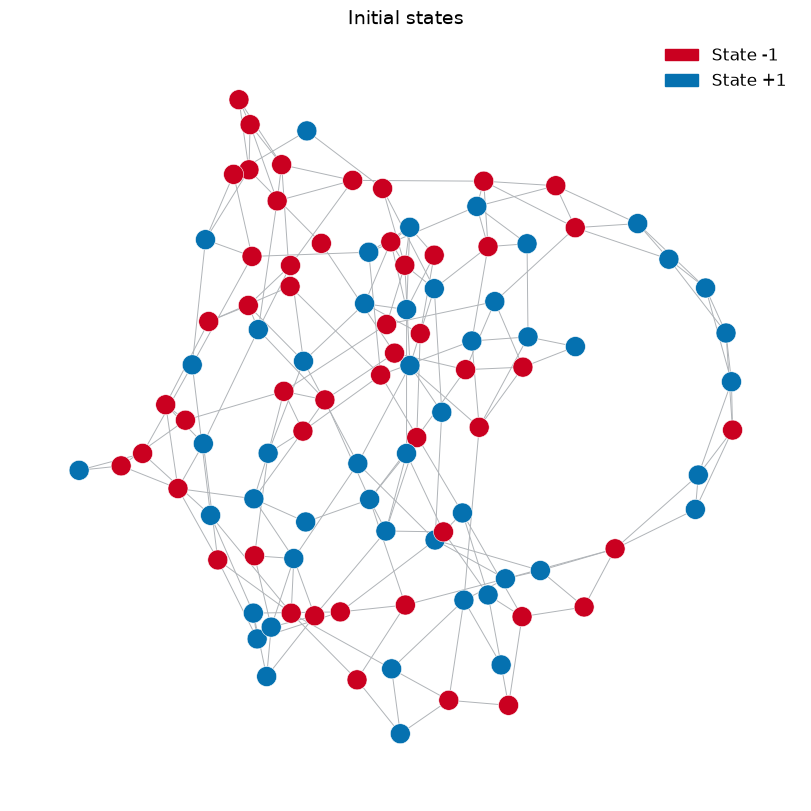

In [3]:
STATE_COLORS = {-1: "#ca0020", 1: "#0571b0"}
legend = [Patch(color=color, label=f"State {s:+d}") for s, color in STATE_COLORS.items()]


def draw_network(ax, states, title):
    ig.plot(
        graph, target=ax, layout=layout,
        vertex_color=[STATE_COLORS[s] for s in states],
        vertex_size=20, vertex_frame_color="white", vertex_frame_width=0.4,
        edge_color="#b0b4b8", edge_width=0.7,
    )
    ax.set_title(title)
    ax.axis("off")


fig, ax = plt.subplots(figsize=(8, 8), layout="constrained")
draw_network(ax, initial_states, "Initial states")
ax.legend(handles=legend, loc="upper right", frameon=False)
# plt.savefig("./figures/voter_initial.pdf")
plt.show()

## 2. Implement the copying rule

Each iteration activates one agent: choose an agent, choose a neighbor, and copy. Each change is immediately available to later updates. We save a copy of the states after every activation so we can plot their evolution.

In [4]:
def simulate_voter(initial_states, neighbors, max_steps, rng):
    # This implementation favors clarity over efficiency.
    # A more efficient implementation could save outputs less often.
    states = initial_states.copy()
    history = [states.copy()]

    for _ in range(max_steps):
        if np.all(states == states[0]):  # Stop once all agents agree.
            break

        agent = rng.integers(len(states))
        if len(neighbors[agent]) > 0:
            neighbor = rng.choice(neighbors[agent])
            states[agent] = states[neighbor]

        history.append(states.copy())

    return np.array(history)

## 3. Run one simulation

Consensus is detected at the activation that produces unanimity; an initially unanimous state has consensus at step 0. If the step limit is reached first, we report that explicitly.

Consensus on state +1 detected at step 5251.


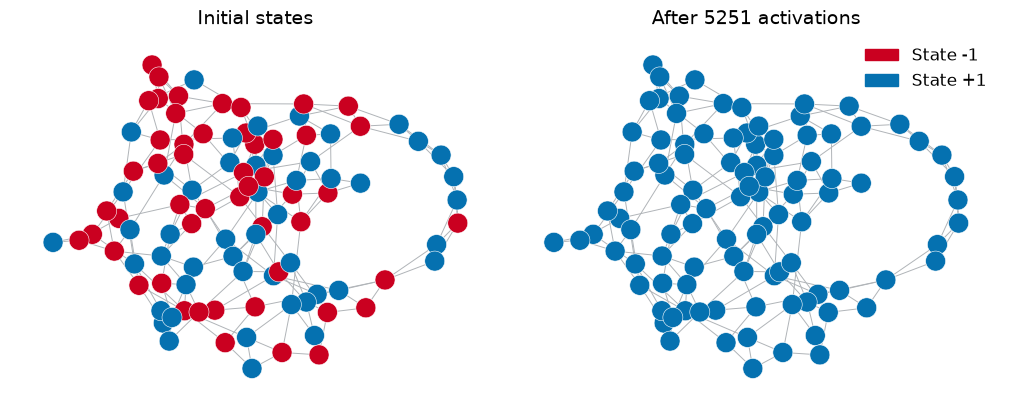

In [5]:
rng = np.random.default_rng(SIMULATION_SEED)
history = simulate_voter(initial_states, neighbors, MAX_STEPS, rng)
final_states = history[-1]
elapsed_steps = len(history) - 1

if np.all(final_states == final_states[0]):
    print(f"Consensus on state {final_states[0]:+d} detected at step {elapsed_steps}.")
else:
    print(f"No consensus within {MAX_STEPS} activations.")

fig, axes = plt.subplots(1, 2, figsize=(10, 4), layout="constrained")
draw_network(axes[0], initial_states, "Initial states")
draw_network(axes[1], final_states, f"After {elapsed_steps} activations")
axes[1].legend(handles=legend, loc="upper right", frameon=False)
# plt.savefig("./figures/voter_final.pdf")
plt.show()

## 4. Follow the fraction in state +1

At each recorded step, `(history == 1).mean(axis=1)` gives the fraction of agents in state $+1$. A fraction of 0 means everyone is in state $-1$; a fraction of 1 means everyone is in state $+1$. Values strictly between 0 and 1 mean that both states are still present. The mean opinion itself ranges from $-1$ to $+1$ and is a different quantity.

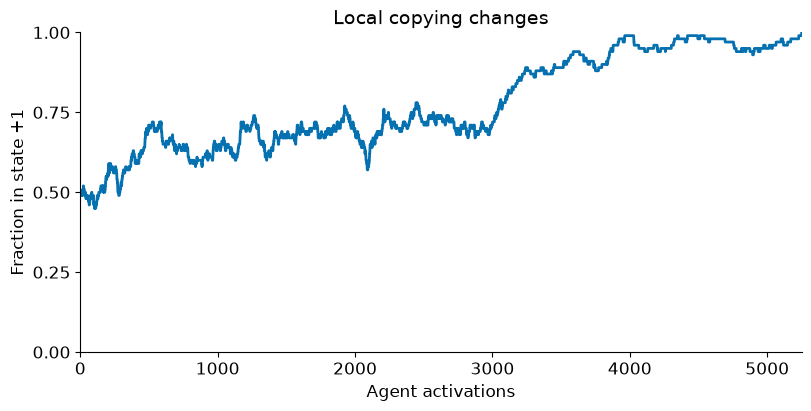

In [6]:
steps = np.arange(len(history))
fraction_one = (history == 1).mean(axis=1)

fig, ax = plt.subplots(figsize=(8, 4), layout="constrained")
ax.plot(steps, fraction_one, color=STATE_COLORS[1], linewidth=2)
ax.set(
    title="Local copying changes",
    xlabel="Agent activations",
    ylabel="Fraction in state +1",
    xlim=(0, max(1, elapsed_steps)), ylim=(-0.03, 1.03),
    yticks=[0, 0.25, 0.5, 0.75, 1],
)
ax.spines[["top", "right"]].set_visible(False)
ax.set_ylim(0,1)
# plt.savefig("./figures/voter_frac_state1.pdf")
plt.show()

## Interpretation and limitations

Agents keep binary states throughout the run. Random copying can increase or decrease the fraction in state +1; the trajectory need not move smoothly toward consensus. Once all agents agree, copying cannot change any state.

This is one stochastic realization on a fixed synthetic network. Agents hold only two possible opinions and copy neighbors uniformly; the model omits external information, individual preferences, and changing relationships. Repeated runs are needed to estimate outcome probabilities and typical consensus times. If consensus is not reached within `MAX_STEPS`, that alone does not establish persistent disagreement.


### Reference

Clifford, P., & Sudbury, A. (1973). *A model for spatial conflict*. Biometrika, 60(3), 581–588. [doi:10.1093/biomet/60.3.581](https://doi.org/10.1093/biomet/60.3.581).